## Phase 5 — Strategic Recommendations

#### Context
Based on 5-phase end-to-end analysis of 9,994 orders across 4 years (2014–2017),
we identified that the company is profitable on paper ($286,397 total profit)
but is silently losing $135,376 every year due to one controllable factor:
**Excessive Discounting.**

#### Data Foundation
Every recommendation below is backed by numbers from our analysis.
These are not opinions — they are data-driven actions.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize']=(12, 5)
plt.rcParams['font.size']=12

In [2]:
df=pd.read_csv(r"C:\Users\hites\Downloads\Superstore_cleaned.csv")
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Ship Date']=pd.to_datetime(df['Ship Date'])
print("Shape:", df.shape)

Shape: (9994, 26)


#### Recommendation 1 visual

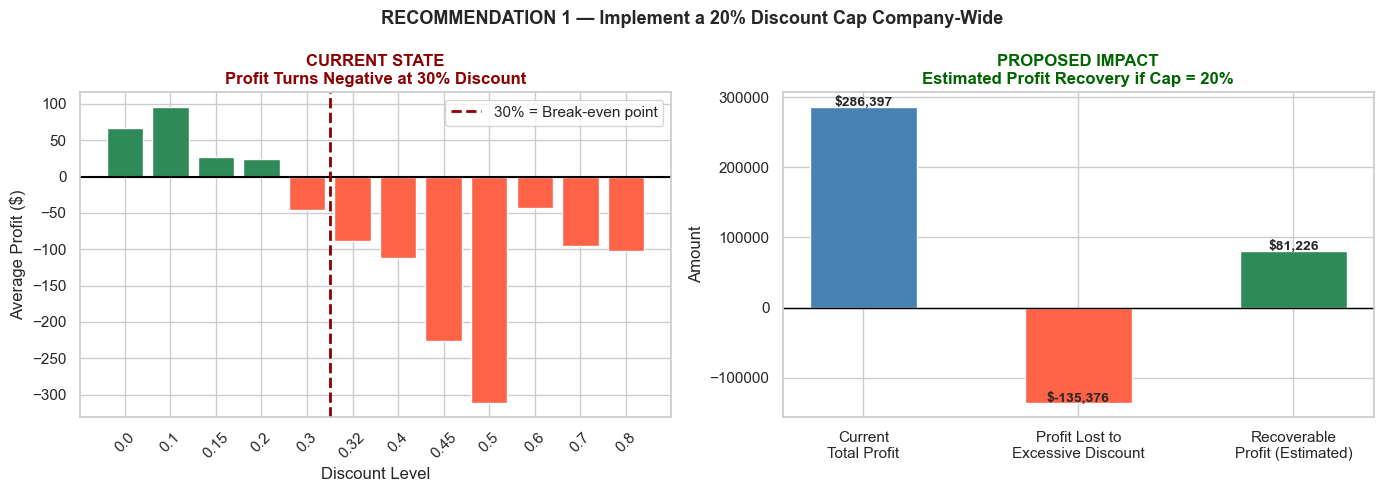

RECOMMENDATION 1: CAP ALL DISCOUNTS AT 20%
Current total profit: $286,397.02
Profit lost to disc >20%: $-135,376.06
Orders with disc >20%:     1,393
% of orders with excessive disc:     13.9%
Estimated recoverable profit:$ 81,225.63
ACTION: Set a hard system limit of 20% max discount.
No sales rep should be able to give more than 20% discount
without written approval from the Regional Manager.


In [3]:
# R1: Cap discounts at 20% — Show the before/after impact
discount_profit=df.groupby('Discount').agg(Avg_Profit=('Profit', 'mean'), Total_Orders=('Order ID', 'count')).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Current state — profit by discount level
colors=['seagreen' if x>0 else 'tomato' for x in discount_profit['Avg_Profit']]
axes[0].bar(discount_profit['Discount'].astype(str), discount_profit['Avg_Profit'], color=colors)
axes[0].axhline(0, color='black', linewidth=1.5)
axes[0].axvline(4.5, color='darkred', linewidth=2, linestyle='--', label='30% = Break-even point')
axes[0].set_title('CURRENT STATE\nProfit Turns Negative at 30% Discount', fontweight='bold', color='darkred')
axes[0].set_xlabel('Discount Level')
axes[0].set_ylabel('Average Profit ($)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# Proposed state — what happens if we cap at 20%
normal=df[df['Discount']<=0.20]
excessive=df[df['Discount']>0.20]
labels=['Current\nTotal Profit', 'Profit Lost to\nExcessive Discount', 'Recoverable\nProfit (Estimated)']
values=[df['Profit'].sum(), excessive['Profit'].sum(), abs(excessive['Profit'].sum()) * 0.6]
bar_cols=['steelblue', 'tomato', 'seagreen']
bars=axes[1].bar(labels, values, color=bar_cols, width=0.5)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('PROPOSED IMPACT\nEstimated Profit Recovery if Cap = 20%', fontweight='bold', color='darkgreen')
axes[1].set_ylabel('Amount')
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+1500,
                 f'${val:,.0f}', ha='center',
                 fontsize=10, fontweight='bold')

plt.suptitle('RECOMMENDATION 1 — Implement a 20% Discount Cap Company-Wide', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('R1_discount_cap.png', dpi=150)
plt.show()

print("="*60)
print("RECOMMENDATION 1: CAP ALL DISCOUNTS AT 20%")
print("="*60)
print(f"Current total profit: ${df['Profit'].sum():>10,.2f}")
print(f"Profit lost to disc >20%: ${excessive['Profit'].sum():>10,.2f}")
print(f"Orders with disc >20%:{len(excessive):>10,}")
print(f"% of orders with excessive disc:" f"{len(excessive)/len(df)*100:>9.1f}%")
print(f"Estimated recoverable profit:" f"${abs(excessive['Profit'].sum())*0.6:>10,.2f}")
print("="*60)
print("ACTION: Set a hard system limit of 20% max discount.")
print("No sales rep should be able to give more than 20% discount")
print("without written approval from the Regional Manager.")

#### Recommendation 2 Visual

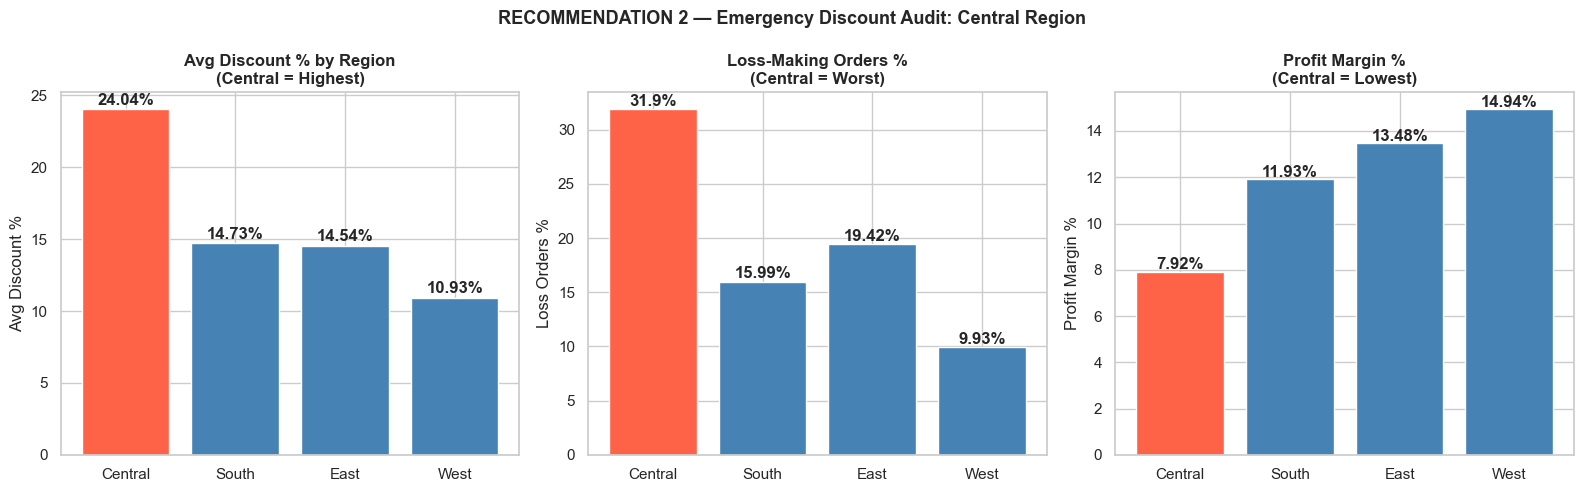

RECOMMENDATION 2: EMERGENCY AUDIT — CENTRAL REGION
Central avg discount:24.04% ← Highest in company
Central loss order rate:31.9% ← 1 in 3 orders loses money
Central profit margin:    7.92% ← Lowest in company
Central total profit:$39,706.36
ACTION: Conduct immediate discount audit in Central region.
Identify which sales reps are giving >20% discounts and why.
Retrain Central region sales team on value-based selling.


In [11]:
# R2: Fix the Central Region — highest discounting, worst profitability
region_data=df.groupby('Region').agg(
    Avg_Discount=('Discount', 'mean'),
    Total_Profit=('Profit', 'sum'),
    Total_Sales=('Sales', 'sum'),
    Loss_Orders=('Profit', lambda x:(x<0).sum()),
    Total_Orders=('Order ID', 'count')
).reset_index()
region_data['Profit_Margin_%']=(region_data['Total_Profit']/region_data['Total_Sales']*100).round(2)
region_data['Avg_Discount_%']=(region_data['Avg_Discount']*100).round(2)
region_data['Loss_%']=(region_data['Loss_Orders']/region_data['Total_Orders']*100).round(2)
region_data=region_data.sort_values('Avg_Discount_%', ascending=False)
fig,axes=plt.subplots(1,3,figsize=(16, 5))

colors_region = ['tomato' if r=='Central' else 'steelblue' for r in region_data['Region']]

axes[0].bar(region_data['Region'], region_data['Avg_Discount_%'], color=colors_region)
for i, v in enumerate(region_data['Avg_Discount_%']):
    axes[0].text(i, v+0.3, f'{v}%', ha='center', fontweight='bold')
axes[0].set_title('Avg Discount % by Region\n(Central = Highest)', fontweight='bold')
axes[0].set_ylabel('Avg Discount %')

axes[1].bar(region_data['Region'], region_data['Loss_%'], color=colors_region)
for i, v in enumerate(region_data['Loss_%']):
    axes[1].text(i, v+0.3, f'{v}%', ha='center', fontweight='bold')
axes[1].set_title('Loss-Making Orders %\n(Central = Worst)', fontweight='bold')
axes[1].set_ylabel('Loss Orders %')

axes[2].bar(region_data['Region'], region_data['Profit_Margin_%'], color=colors_region)
for i, v in enumerate(region_data['Profit_Margin_%']):
    axes[2].text(i, v+0.1, f'{v}%', ha='center', fontweight='bold')
axes[2].set_title('Profit Margin %\n(Central = Lowest)', fontweight='bold')
axes[2].set_ylabel('Profit Margin %')

plt.suptitle('RECOMMENDATION 2 — Emergency Discount Audit: Central Region', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('R2_central_region.png', dpi=150)
plt.show()

central=df[df['Region']=='Central']
print("="*60)
print("RECOMMENDATION 2: EMERGENCY AUDIT — CENTRAL REGION")
print("="*60)
print(f"Central avg discount:{central['Discount'].mean()*100:.2f}%"
      f" ← Highest in company")
print(f"Central loss order rate:"
      f"{len(central[central['Profit']<0])/len(central)*100:.1f}%"
      f" ← 1 in 3 orders loses money")
print(f"Central profit margin:    "
      f"{central['Profit'].sum()/central['Sales'].sum()*100:.2f}%"
      f" ← Lowest in company")
print(f"Central total profit:${central['Profit'].sum():,.2f}")
print("="*60)
print("ACTION: Conduct immediate discount audit in Central region.")
print("Identify which sales reps are giving >20% discounts and why.")
print("Retrain Central region sales team on value-based selling.")

#### Recommendation 3 Visual

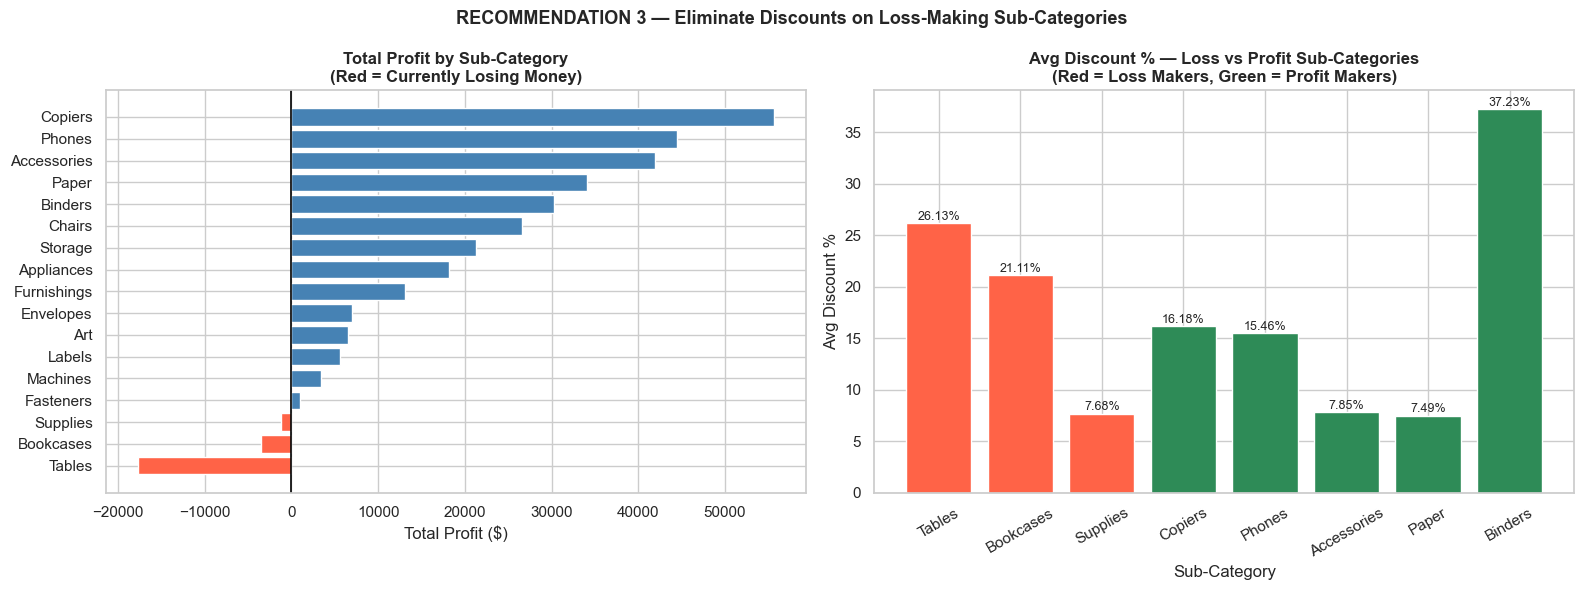

RECOMMENDATION 3: STOP DISCOUNTING LOSS-MAKING PRODUCTS
Tables:
Total Profit:$-17,725.48
Avg Discount:26.13%
Profit Margin:-8.56%

Bookcases:
Total Profit:$-3,472.56
Avg Discount:21.11%
Profit Margin:-3.02%

Supplies:
Total Profit:$-1,189.10
Avg Discount:7.68%
Profit Margin:-2.55%

ACTION: Remove all discounts on Tables, Bookcases & Supplies.
These sub-categories lose money even before discounting.
If they can't sell at full price, evaluate discontinuing them.


In [5]:
# R3: Stop discounting Tables & Bookcases — they lose money regardless
loss_cats=['Tables', 'Bookcases', 'Supplies']
subcat_full=df.groupby('Sub-Category').agg(
    Total_Profit=('Profit', 'sum'),
    Total_Sales=('Sales', 'sum'),
    Avg_Discount=('Discount', 'mean'),
    Total_Orders=('Order ID', 'count')
).reset_index()
subcat_full['Profit_Margin_%']=(subcat_full['Total_Profit']/subcat_full['Total_Sales']*100).round(2)
subcat_full['Avg_Discount_%']=(subcat_full['Avg_Discount']*100).round(2)
subcat_full=subcat_full.sort_values('Total_Profit')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# All sub-categories profit
colors=['tomato' if x<0 else 'steelblue' for x in subcat_full['Total_Profit']]
axes[0].barh(subcat_full['Sub-Category'], subcat_full['Total_Profit'], color=colors)
axes[0].axvline(0, color='black', linewidth=1.2)
axes[0].set_title('Total Profit by Sub-Category\n(Red = Currently Losing Money)', fontweight='bold')
axes[0].set_xlabel('Total Profit ($)')

# Loss sub-categories — discount vs profit
loss_df=subcat_full[subcat_full['Sub-Category'].isin(loss_cats)]
profit_df=subcat_full[subcat_full['Total_Profit']>0].nlargest(5, 'Total_Profit')
compare=pd.concat([loss_df, profit_df])
bar_colors2=['tomato' if x<0 else 'seagreen' for x in compare['Total_Profit']]
axes[1].bar(compare['Sub-Category'], compare['Avg_Discount_%'], color=bar_colors2)
axes[1].set_title('Avg Discount % — Loss vs Profit Sub-Categories\n'
                   '(Red = Loss Makers, Green = Profit Makers)', fontweight='bold')
axes[1].set_ylabel('Avg Discount %')
axes[1].set_xlabel('Sub-Category')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(compare['Avg_Discount_%']):
    axes[1].text(i, v + 0.3, f'{v}%', ha='center', fontsize=9)

plt.suptitle('RECOMMENDATION 3 — Eliminate Discounts on Loss-Making Sub-Categories', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('R3_loss_subcategories.png', dpi=150)
plt.show()

print("="*60)
print("RECOMMENDATION 3: STOP DISCOUNTING LOSS-MAKING PRODUCTS")
print("="*60)
for cat in loss_cats:
    row = subcat_full[subcat_full['Sub-Category']==cat].iloc[0]
    print(f"{cat}:")
    print(f"Total Profit:${row['Total_Profit']:,.2f}")
    print(f"Avg Discount:{row['Avg_Discount_%']}%")
    print(f"Profit Margin:{row['Profit_Margin_%']}%")
    print()
print("ACTION: Remove all discounts on Tables, Bookcases & Supplies.")
print("These sub-categories lose money even before discounting.")
print("If they can't sell at full price, evaluate discontinuing them.")

#### Recommendation 4 Visual

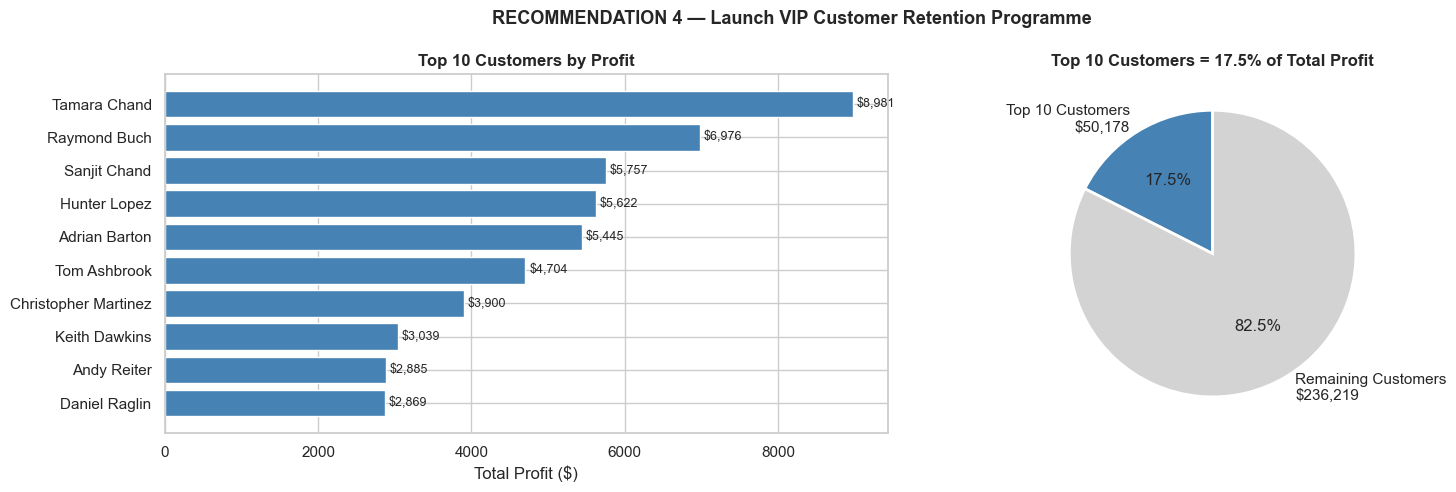

RECOMMENDATION 4: VIP CUSTOMER RETENTION PROGRAMME
Top 10 customers generate: $50,178.07 profit
That is 17.5% of total company profit
From only 10 customers out of 793 total

ACTION: Assign a dedicated account manager to each of the
top 10 customers. Offer them priority shipping and early
access to new products — NOT discounts.
            Customer Name  Total_Profit  Total_Sales  Total_Orders
730          Tamara Chand     8981.3239    19052.218            12
622          Raymond Buch     6976.0959    15117.339            18
671          Sanjit Chand     5757.4119    14142.334            22
334          Hunter Lopez     5622.4292    12873.298            11
6           Adrian Barton     5444.8055    14473.571            20
757          Tom Ashbrook     4703.7883    14595.620            10
157  Christopher Martinez     3899.8904     8954.020            10
431         Keith Dawkins     3038.6254     8181.256            28
35            Andy Reiter     2884.6208     6608.448             9


In [7]:
# R4: Protect and grow top 10 customers — VIP loyalty programme
top10=df.groupby('Customer Name').agg(
    Total_Profit=('Profit', 'sum'),
    Total_Sales=('Sales', 'sum'),
    Total_Orders=('Order ID', 'count')
).reset_index().sort_values('Total_Profit', ascending=False).head(10)

top10_profit=top10['Total_Profit'].sum()
total_profit=df['Profit'].sum()
top10_pct=top10_profit / total_profit*100
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 10 customer bar chart
axes[0].barh(top10['Customer Name'], top10['Total_Profit'], color='steelblue')
axes[0].set_title('Top 10 Customers by Profit', fontweight='bold')
axes[0].set_xlabel('Total Profit ($)')
axes[0].gca=axes[0]
axes[0].invert_yaxis()
for i, v in enumerate(top10['Total_Profit']):
    axes[0].text(v+50, i, f'${v:,.0f}', va='center', fontsize=9)

# Pie — top 10 vs everyone else
pie_vals=[top10_profit, total_profit-top10_profit]
pie_labels=[f'Top 10 Customers\n${top10_profit:,.0f}',
            f'Remaining Customers\n${total_profit-top10_profit:,.0f}']
axes[1].pie(pie_vals, labels=pie_labels, autopct='%1.1f%%', colors=['steelblue', 'lightgrey'], startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title(f'Top 10 Customers = {top10_pct:.1f}% of Total Profit', fontweight='bold')

plt.suptitle('RECOMMENDATION 4 — Launch VIP Customer Retention Programme', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('R4_vip_customers.png', dpi=150)
plt.show()

print("="*60)
print("RECOMMENDATION 4: VIP CUSTOMER RETENTION PROGRAMME")
print("="*60)
print(f"Top 10 customers generate: ${top10_profit:,.2f} profit")
print(f"That is {top10_pct:.1f}% of total company profit")
print(f"From only {len(top10)} customers out of "
      f"{df['Customer Name'].nunique()} total")
print()
print("ACTION: Assign a dedicated account manager to each of the")
print("top 10 customers. Offer them priority shipping and early")
print("access to new products — NOT discounts.")
print(top10[['Customer Name', 'Total_Profit', 'Total_Sales', 'Total_Orders']])

#### Recommendation 5 Visual

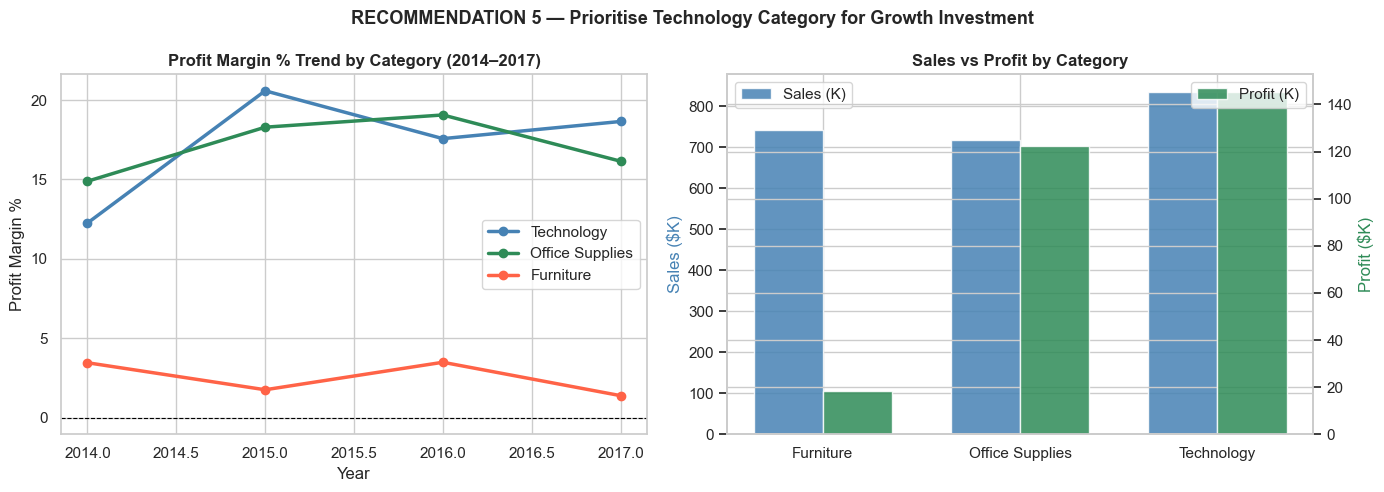

RECOMMENDATION 5: SHIFT FOCUS TO TECHNOLOGY CATEGORY
Technology profit margin:17.40%
Furniture profit margin:2.49%
Technology total profit:$145,454.95
Furniture total profit:$18,451.27

ACTION: Increase marketing budget for Technology by 20%.
Reduce shelf space and promotional spend on Furniture.
Specifically push Copiers ($55K profit) and Phones ($44K profit).


In [12]:
# R5: Focus on Technology — best margin, best growth potential
cat_yearly=df.groupby(['Order Year', 'Category']).agg(Total_Sales=('Sales', 'sum'), Total_Profit=('Profit', 'sum')).reset_index()
cat_yearly['Profit_Margin_%']=(cat_yearly['Total_Profit']/cat_yearly['Total_Sales']*100).round(2)
fig,axes=plt.subplots(1,2,figsize=(14, 5))

# Profit margin trend by category over years
for cat, color in zip(['Technology', 'Office Supplies', 'Furniture'], ['steelblue', 'seagreen', 'tomato']):
    data=cat_yearly[cat_yearly['Category']==cat]
    axes[0].plot(data['Order Year'], data['Profit_Margin_%'], marker='o', label=cat, color=color, linewidth=2.5)
axes[0].set_title('Profit Margin % Trend by Category (2014–2017)', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Profit Margin %')
axes[0].legend()
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')

# Sales mix vs profit mix
cat_summary = df.groupby('Category').agg(Total_Sales=('Sales', 'sum'), Total_Profit=('Profit', 'sum')).reset_index()
x=range(len(cat_summary))
width=0.35
bars1=axes[1].bar([i-width/2 for i in x], cat_summary['Total_Sales']/1000, width, label='Sales (K)', color='steelblue', alpha=0.85)
ax2=axes[1].twinx()
bars2=ax2.bar([i+width/2 for i in x], cat_summary['Total_Profit']/1000, width, label='Profit (K)', color='seagreen', alpha=0.85)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(cat_summary['Category'])
axes[1].set_ylabel('Sales ($K)', color='steelblue')
ax2.set_ylabel('Profit ($K)', color='seagreen')
axes[1].set_title('Sales vs Profit by Category', fontweight='bold')
axes[1].legend(loc='upper left')
ax2.legend(loc='upper right')

plt.suptitle('RECOMMENDATION 5 — Prioritise Technology Category for Growth Investment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('R5_technology_focus.png', dpi=150)
plt.show()

tech = df[df['Category']=='Technology']
furn = df[df['Category']=='Furniture']
print("="*60)
print("RECOMMENDATION 5: SHIFT FOCUS TO TECHNOLOGY CATEGORY")
print("="*60)
print(f"Technology profit margin:"
      f"{tech['Profit'].sum()/tech['Sales'].sum()*100:.2f}%")
print(f"Furniture profit margin:"
      f"{furn['Profit'].sum()/furn['Sales'].sum()*100:.2f}%")
print(f"Technology total profit:${tech['Profit'].sum():,.2f}")
print(f"Furniture total profit:${furn['Profit'].sum():,.2f}")
print()
print("ACTION: Increase marketing budget for Technology by 20%.")
print("Reduce shelf space and promotional spend on Furniture.")
print("Specifically push Copiers ($55K profit) and Phones ($44K profit).")

#### Final Executive Summary

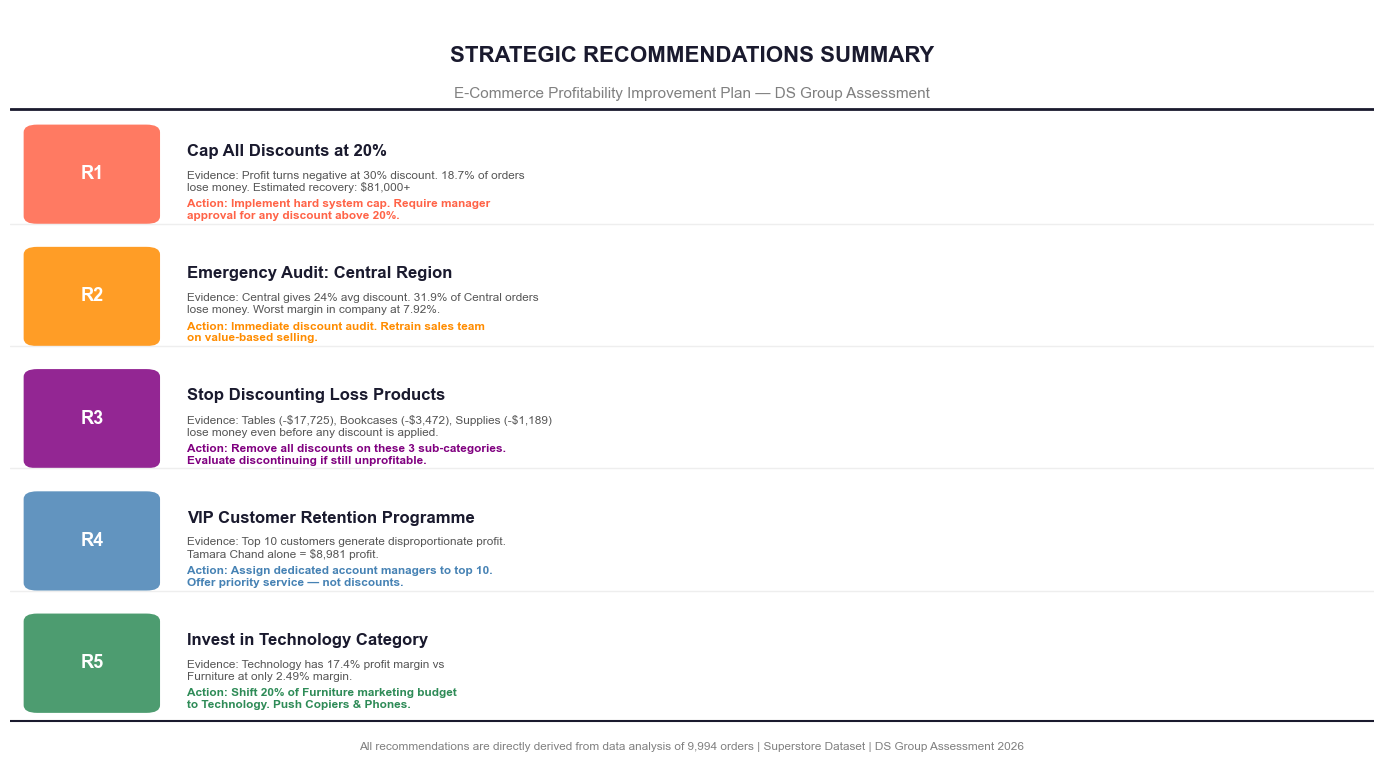

In [10]:
fig,ax=plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Title
ax.text(5, 9.4, 'STRATEGIC RECOMMENDATIONS SUMMARY', ha='center', va='center', fontsize=16, fontweight='bold', color='#1a1a2e')
ax.text(5, 8.9, 'E-Commerce Profitability Improvement Plan — DS Group Assessment', ha='center', va='center', fontsize=11, color='gray')
ax.axhline(8.7, color='#1a1a2e', linewidth=2)

recommendations=[
    ('R1', 'Cap All Discounts at 20%',
     'Profit turns negative at 30% discount. 18.7% of orders\n'
     'lose money. Estimated recovery: $81,000+',
     'Implement hard system cap. Require manager\n'
     'approval for any discount above 20%.',
     'tomato'),
    ('R2', 'Emergency Audit: Central Region',
     'Central gives 24% avg discount. 31.9% of Central orders\n'
     'lose money. Worst margin in company at 7.92%.',
     'Immediate discount audit. Retrain sales team\n'
     'on value-based selling.',
     'darkorange'),
    ('R3', 'Stop Discounting Loss Products',
     'Tables (-$17,725), Bookcases (-$3,472), Supplies (-$1,189)\n'
     'lose money even before any discount is applied.',
     'Remove all discounts on these 3 sub-categories.\n'
     'Evaluate discontinuing if still unprofitable.',
     'purple'),
    ('R4', 'VIP Customer Retention Programme',
     'Top 10 customers generate disproportionate profit.\n'
     'Tamara Chand alone = $8,981 profit.',
     'Assign dedicated account managers to top 10.\n'
     'Offer priority service — not discounts.',
     'steelblue'),
    ('R5', 'Invest in Technology Category',
     'Technology has 17.4% profit margin vs\n'
     'Furniture at only 2.49% margin.',
     'Shift 20% of Furniture marketing budget\n'
     'to Technology. Push Copiers & Phones.',
     'seagreen'),
]

y_positions=[7.8, 6.2, 4.6, 3.0, 1.4]
for (code, title, evidence, action, color), y in zip(recommendations, y_positions):
    ax.add_patch(mpatches.FancyBboxPatch((0.2, y - 0.5), 0.8, 1.1, boxstyle='round,pad=0.1', facecolor=color, edgecolor='none', alpha=0.85))
    ax.text(0.6, y+0.05, code, ha='center', va='center', fontsize=13, fontweight='bold', color='white')
    ax.text(1.3, y+0.35, title, va='center', fontsize=12, fontweight='bold', color='#1a1a2e')
    ax.text(1.3, y-0.05, f'Evidence: {evidence}', va='center', fontsize=8.5, color='#555555')
    ax.text(1.3, y-0.42, f'Action: {action}', va='center', fontsize=8.5, color=color, fontweight='bold')

    if y!=y_positions[-1]:
        ax.axhline(y-0.6, color='#eeeeee', linewidth=1)

ax.axhline(0.7, color='#1a1a2e', linewidth=1.5)
ax.text(5, 0.35,
        'All recommendations are directly derived from data analysis of '
        '9,994 orders | Superstore Dataset | DS Group Assessment 2026',
        ha='center', va='center', fontsize=8.5, color='gray')

plt.tight_layout()
plt.savefig('R0_executive_summary.png', dpi=150, bbox_inches='tight')
plt.show()

### Summary

## Phase 5 — Complete Recommendations Summary

| # | Recommendation | Data Evidence | Specific Action | Expected Impact |
|---|---|---|---|---|
| R1 | Cap discounts at 20% | Profit goes negative at 30% disc | Hard system limit of 20% max | Recover ~$81K lost profit |
| R2 | Audit Central Region | 31.9% loss orders, 24% avg disc | Immediate audit + sales retraining | Improve 7.92% margin |
| R3 | Stop discounting Tables/Bookcases/Supplies | -$17,725 loss before any discount | Remove all discounts on these 3 | Eliminate guaranteed losses |
| R4 | VIP customer programme | Top 10 = disproportionate profit | Dedicated account managers | Protect highest-value relationships |
| R5 | Invest in Technology | 17.4% margin vs Furniture 2.49% | Shift 20% marketing budget | Maximise highest-margin category |

### One Line Answer to the CEO's Question:
**"Your company is generating $286K profit but leaving $135K on the table
every year by giving discounts above 20% — especially in the Central region
on Furniture products. Cap discounts at 20%, fix Central region, and stop
discounting loss-making products. You can recover over $80,000 in profit
without acquiring a single new customer."**